# ===============================
# Task 3: Sentiment & Correlation
# ===============================

In [2]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (only once)
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# =====================================================
# 1. LOAD DATA
# =====================================================

In [3]:
# Example paths — replace with yours
news_df = pd.read_csv(r"C:\Users\Administrator\Desktop\FNSPID-KIFYA-week1\data\raw_analyst_ratings.csv")               # must include "date", "headline"
stock_df = pd.read_csv(r"C:\Users\Administrator\Desktop\FNSPID-KIFYA-week1\data\GOOG.csv")      # must include "date", "close"

# =====================================================
# 2. DATE NORMALIZATION
# =====================================================

In [4]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce").dt.date
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce").dt.date


# =====================================================
# 3. SENTIMENT ANALYSIS
# =====================================================

In [5]:
sia = SentimentIntensityAnalyzer()

def compute_sentiment(text):
    score = sia.polarity_scores(str(text))
    return score["compound"]

news_df["sentiment"] = news_df["headline"].apply(compute_sentiment)

In [6]:
news_df.head(5            )

,Unnamed: 0,headline,url,publisher,date,stock,sentiment
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,0.000
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03,A,0.000
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26,A,0.000
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22,A,0.000
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22,A,0.296


# =====================================================
# 4. AGGREGATE DAILY SENTIMENT
# =====================================================

In [7]:
daily_sentiment = (
    news_df.groupby("date")["sentiment"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment": "daily_sentiment"})
)

In [8]:
daily_sentiment.head()

,date,daily_sentiment
0,2011-04-27,0.00000
1,2011-04-28,0.12500
2,2011-04-29,0.36755
3,2011-04-30,0.20230
4,2011-05-01,0.00000


# =====================================================
# 5. CALCULATE DAILY STOCK RETURNS
# =====================================================

In [9]:
stock_df = stock_df.sort_values("Date")
stock_df["daily_return"] = stock_df["Close"].pct_change() * 100

# Drop first NaN return
stock_df = stock_df.dropna(subset=["daily_return"])

daily_returns = stock_df[["Date", "daily_return"]]

In [10]:
daily_returns.head()

,Date,daily_return
1,2009-01-05,2.094467
2,2009-01-06,1.832057
3,2009-01-07,-3.607137
4,2009-01-08,0.987523
5,2009-01-09,-3.112007


# =====================================================
# 6. MERGE SENTIMENT + RETURNS
# =====================================================

In [14]:
# Fix daily_returns column names
daily_returns = daily_returns.rename(columns={"Date": "date"})

# Merge
merged = pd.merge(daily_sentiment, daily_returns, on="date", how="inner")

print(merged.head(15))


          date  daily_sentiment  daily_return
0   2011-04-27         0.000000      0.927145
1   2011-04-28         0.125000      0.039042
2   2011-04-29         0.367550      1.139468
3   2011-05-02         0.136444     -1.018188
4   2011-05-03         0.000000     -0.867126
5   2011-05-05        -0.042667     -0.283698
6   2011-05-06         0.067433      0.192771
7   2011-05-09        -0.222933      0.444619
8   2011-05-11         0.196667     -1.328639
9   2011-05-12         0.202300     -0.074692
10  2011-05-13         0.185475     -1.027952
11  2011-05-16         0.000000     -2.101784
12  2011-05-17        -0.045567      2.322444
13  2011-05-18         0.000000     -0.122533
14  2011-05-19         0.000000      0.271794


# =====================================================
# 7. CORRELATION ANALYSIS
# =====================================================

In [15]:
correlation = merged["daily_sentiment"].corr(merged["daily_return"])
print("\nPearson Correlation between sentiment and daily returns:")
print(correlation)


Pearson Correlation between sentiment and daily returns:
0.024688607333378076


# Scatter plot (optional)

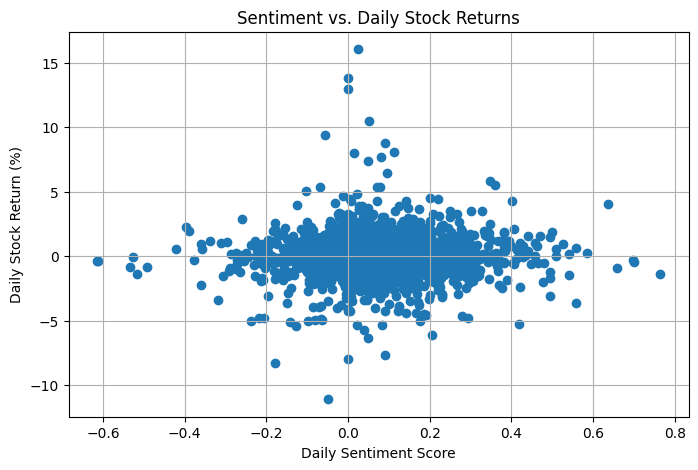

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(merged["daily_sentiment"], merged["daily_return"])
plt.xlabel("Daily Sentiment Score")
plt.ylabel("Daily Stock Return (%)")
plt.title("Sentiment vs. Daily Stock Returns")
plt.grid(True)
plt.show()